In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("household_power_consumption.txt", sep=";")
df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17936\2850678157.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.txt", sep=";")


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [5]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [6]:
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [8]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)
df.set_index("Datetime", inplace=True)

In [9]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
df.drop(columns=["Date", "Time"], axis=1, inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [12]:
## Dataset overview
print(df.shape)
df.info()
df.describe().T

(2075259, 7)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


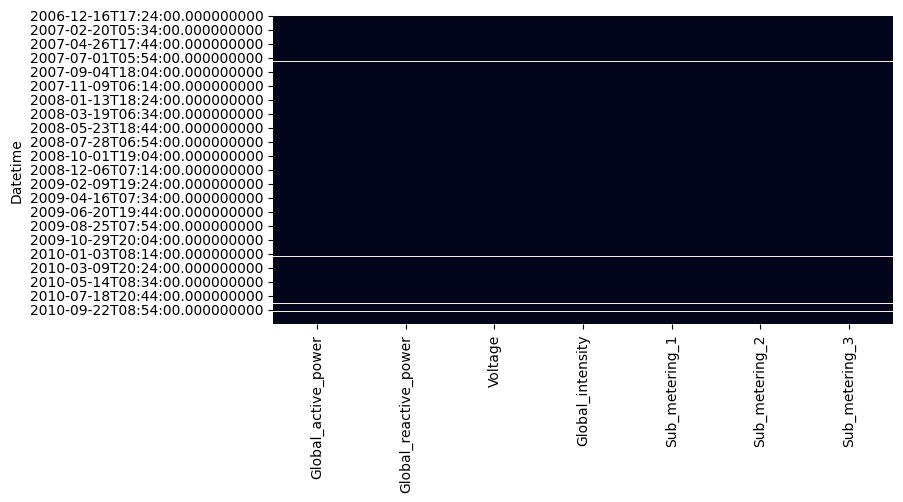

In [13]:
## Missing values
import matplotlib.pyplot as plt
import seaborn as sns

print(df.isnull().sum())

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [ ]:
## All seven numeric columns have exactly 25,979 missing values

In [14]:
df.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [15]:
## percentage of missing values in each column
missing = df.isnull().sum() / len(df) * 100
print(missing)

Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
dtype: float64


In [16]:
## for a time-series dataset, it is better to fill missing values with prev ones
df.fillna(method="ffill", inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17936\1910885677.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [17]:
df.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

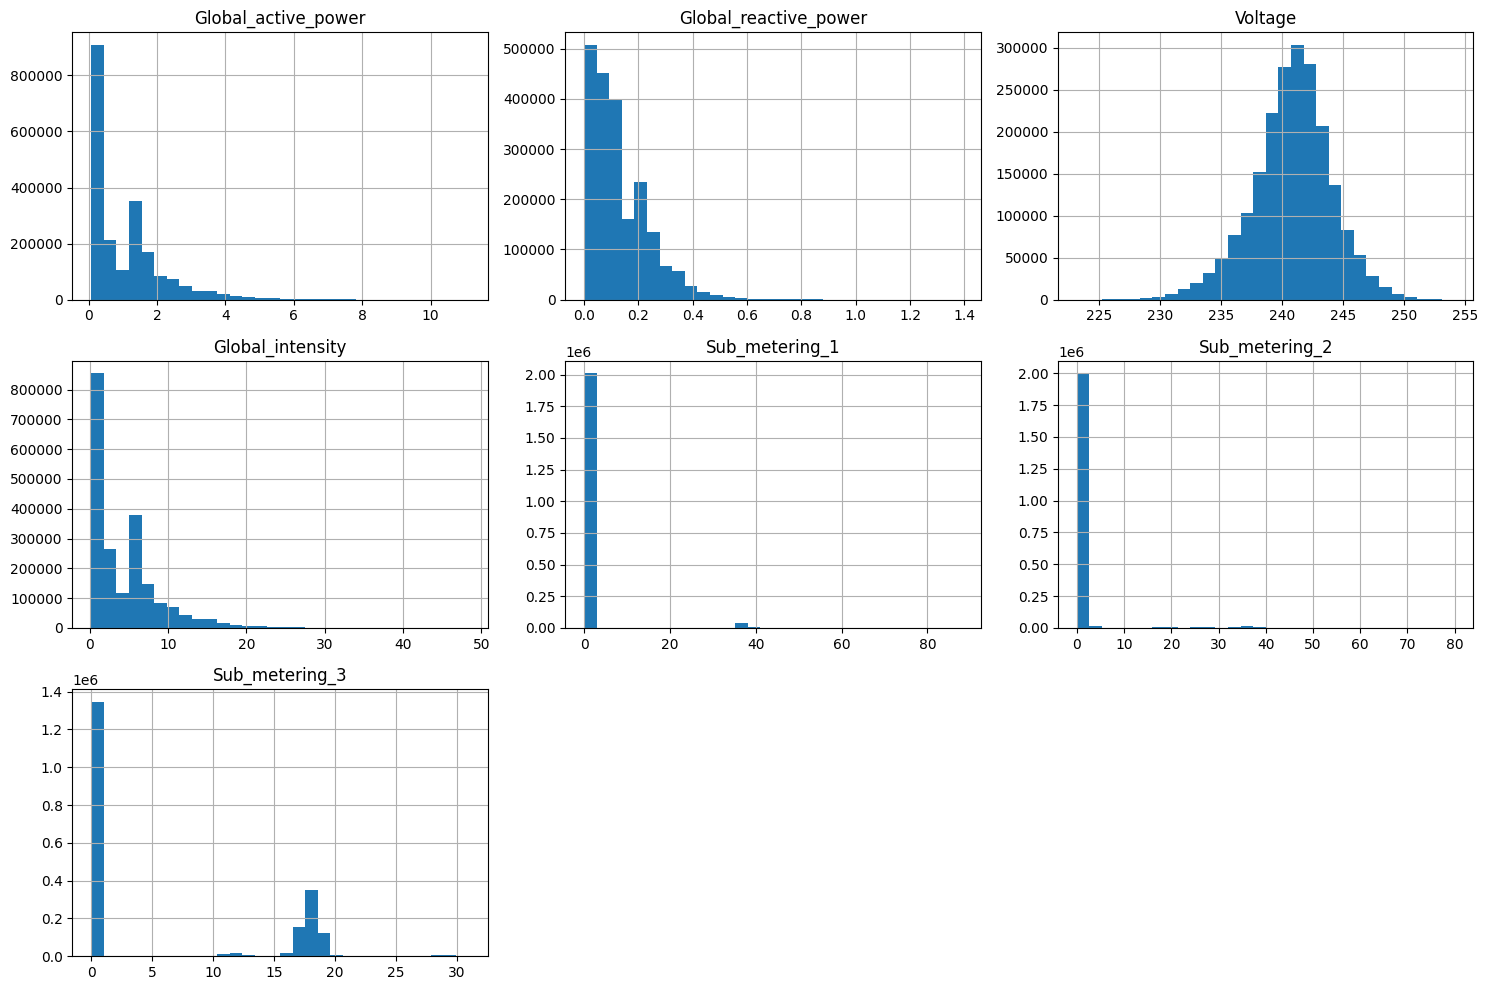

In [18]:
# distribution of features
df.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

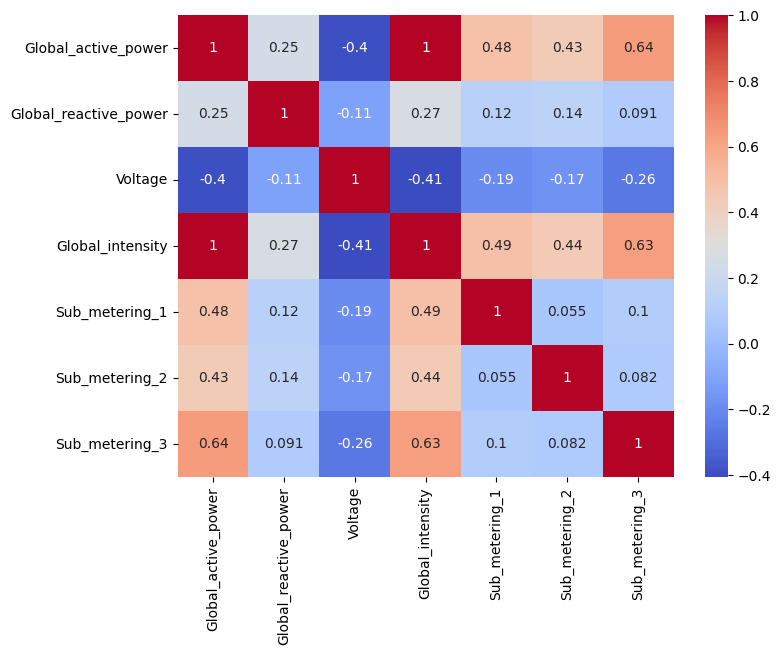

In [20]:
# co-relation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

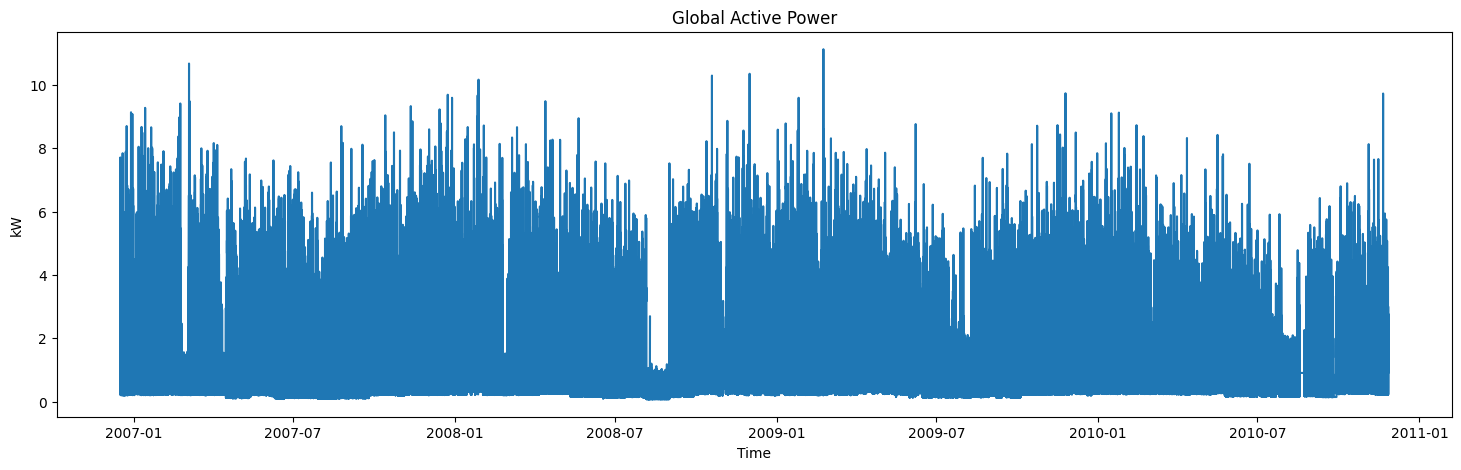

In [21]:
# Trend
plt.figure(figsize=(18,5))

plt.plot(df.index, df["Global_active_power"])

plt.title("Global Active Power")
plt.xlabel("Time")
plt.ylabel("kW")

plt.show()

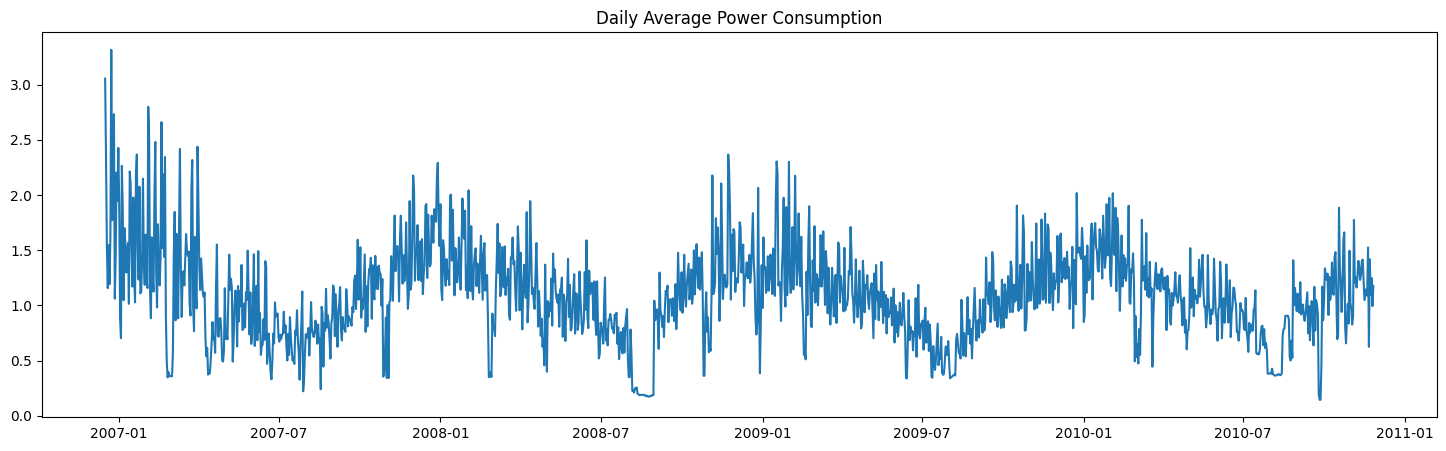

In [22]:
## Daily consuption
daily = df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(18,5))
plt.plot(daily)
plt.title("Daily Average Power Consumption")
plt.show()

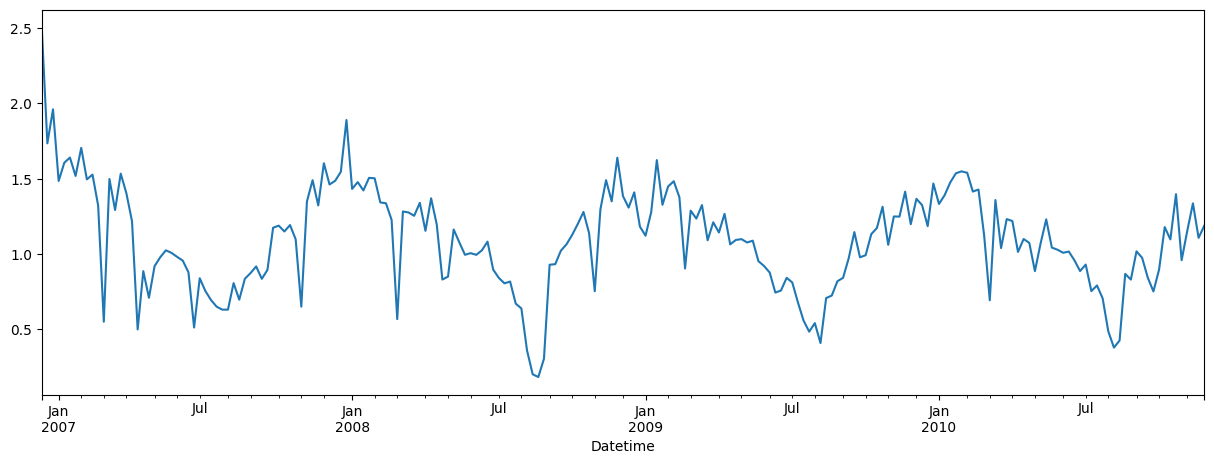

In [ ]:
# weekly consumption
weekly = df["Global_active_power"].resample("W").mean()

weekly.plot(figsize=(15,5))
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17936\1699771000.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df["Global_active_power"].resample("M").mean()


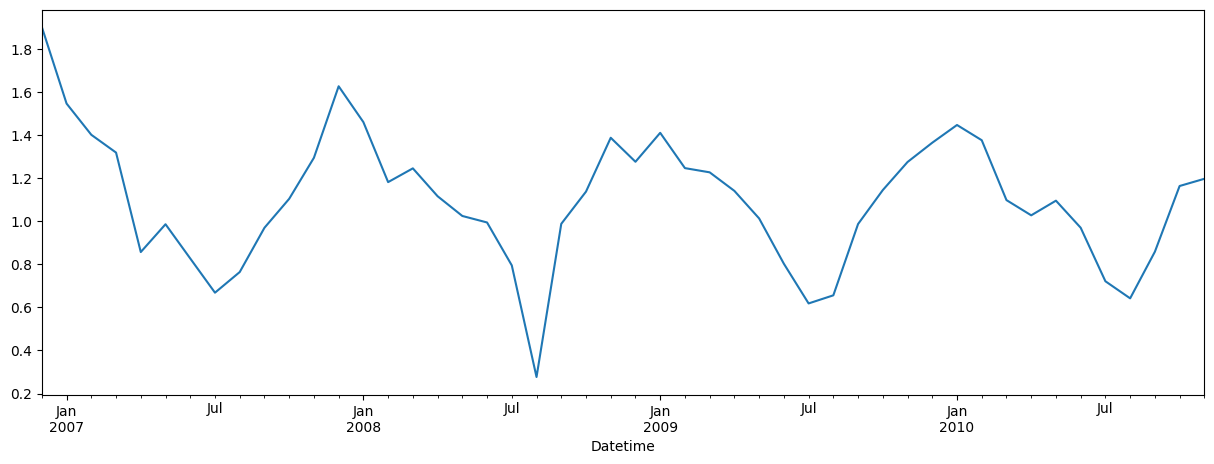

In [24]:
# Monthly consumption
monthly = df["Global_active_power"].resample("M").mean()

monthly.plot(figsize=(15,5))
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17936\4059422596.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df["Global_active_power"].resample("Y").mean()


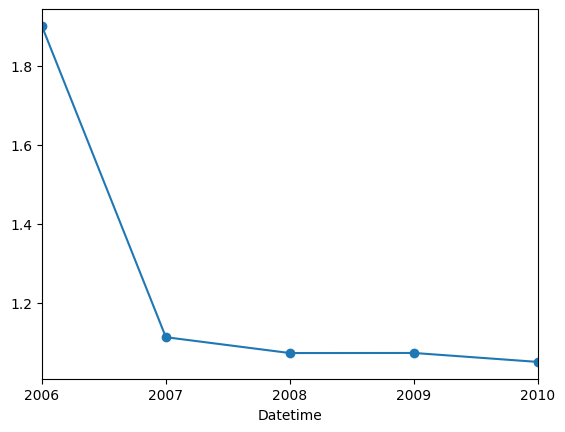

In [25]:
# Yearly consumption
yearly = df["Global_active_power"].resample("Y").mean()

yearly.plot(marker='o')
plt.show()

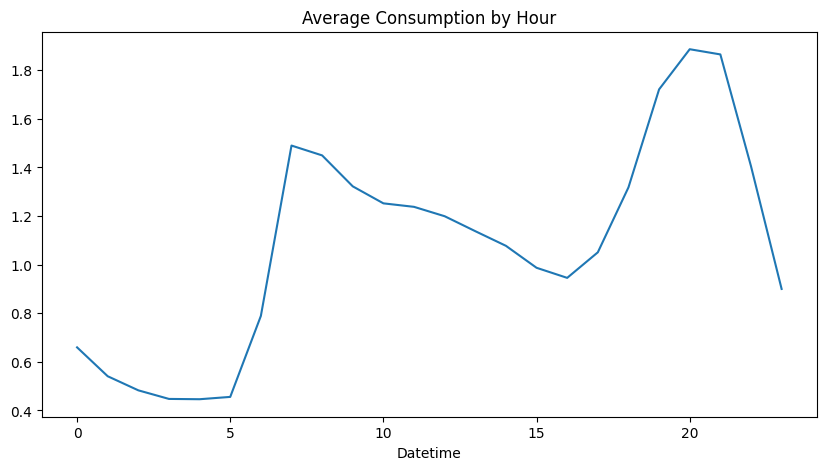

In [26]:
# hour-wise pattern
hourly = df.groupby(df.index.hour)["Global_active_power"].mean()

hourly.plot(figsize=(10,5))
plt.title("Average Consumption by Hour")
plt.show()

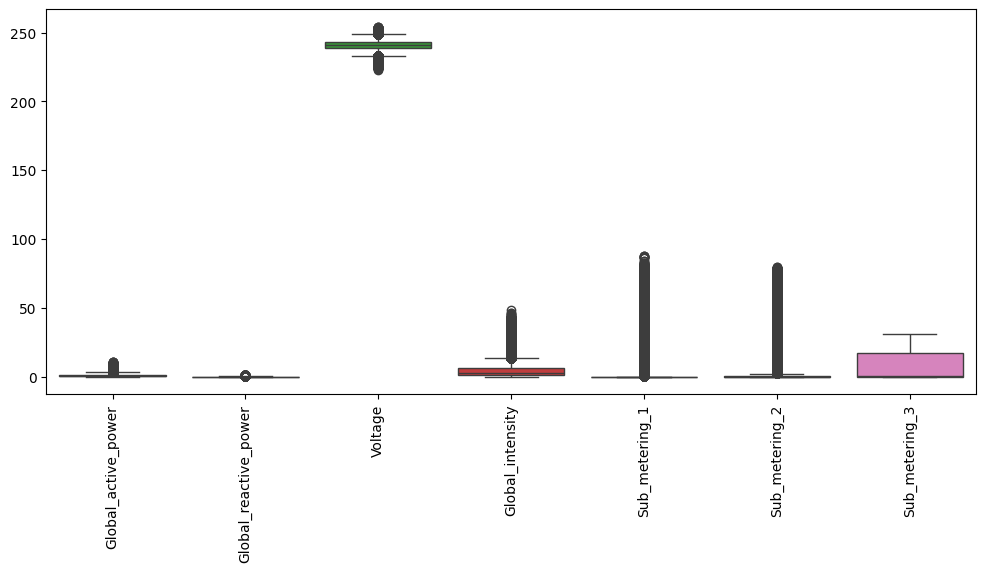

In [27]:
## Outlier detection
plt.figure(figsize=(12,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)
scaled_df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,2.971815,2.618973,-1.854882,3.116440,-0.181657,-0.049761,1.257014
2006-12-16 17:25:00,4.058057,2.778952,-2.228850,4.155571,-0.181657,-0.049761,1.138242
2006-12-16 17:26:00,4.071350,3.329993,-2.333932,4.155571,-0.181657,0.123044,1.257014
2006-12-16 17:27:00,4.084643,3.365544,-2.194853,4.155571,-0.181657,-0.049761,1.257014
2006-12-16 17:28:00,2.449583,3.596626,-1.595268,2.529104,-0.181657,-0.049761,1.257014


In [30]:
print(scaled_df.mean())
print(scaled_df.std())

Global_active_power     -5.434374e-17
Global_reactive_power    1.051814e-17
Voltage                  3.506048e-15
Global_intensity         3.155443e-17
Sub_metering_1           8.765120e-17
Sub_metering_2           1.402419e-17
Sub_metering_3           7.012096e-17
dtype: float64
Global_active_power      1.0
Global_reactive_power    1.0
Voltage                  1.0
Global_intensity         1.0
Sub_metering_1           1.0
Sub_metering_2           1.0
Sub_metering_3           1.0
dtype: float64


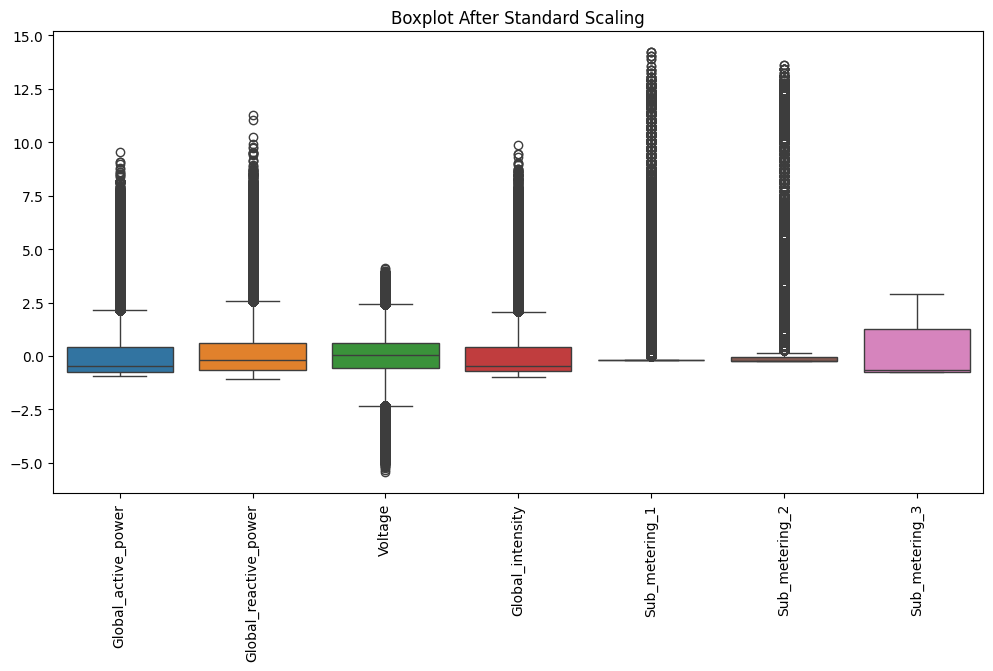

In [31]:
# after scaling
plt.figure(figsize=(12,6))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=90)
plt.title("Boxplot After Standard Scaling")
plt.show()

In [32]:
import os

path = "."  # Current directory

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "    " * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

./
    eda.ipynb
    household_power_consumption.txt
